In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
from google.colab import drive
drive.mount("content")

Mounted at content


In [3]:
#three datasets given fort this project
f1 = pd.read_csv("/content/content/MyDrive/SA_XBT_trade_dataset (1).csv")
f2 = pd.read_csv("/content/content/MyDrive/SA_XBT_trade_dataset (2).csv")
f3 = pd.read_csv("/content/content/MyDrive/SA_XBT_trade_dataset.csv")

In [ ]:
f1.head()# f1 considered as dataset1, exploring the first five rows

,reporting_country,reporting_country_code,border_point,source,source_country_code,destination,destination_country_code,cpcv2,product,indicator_name,...,value_three_years_ago,value_four_years_ago,value_five_years_ago,two_year_average,five_year_average,pct_change_from_one_month_ago,pct_change_from_one_year_ago,pct_change_from_five_year_average,collection_schedule,data_usage_policy
0,Kenya,KE,Malaba,Uganda,UG,Kenya,KE,R01444AA,Sesame Seed,TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public
1,Kenya,KE,Malaba,Uganda,UG,Kenya,KE,R01142AC,Sorghum (Red),TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public
2,Kenya,KE,Malaba,Uganda,UG,Kenya,KE,R01709AD,Gram Pulse (Green),TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public
3,Kenya,KE,Malaba,Uganda,UG,Kenya,KE,P21421AA,Groundnuts (Shelled),TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public
4,Kenya,KE,Malaba,Uganda,UG,Kenya,KE,R01182AC,Millet (Finger),TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public


In [ ]:
f1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21390 entries, 0 to 21389
Data columns (total 46 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   reporting_country                   21390 non-null  object 
 1   reporting_country_code              21390 non-null  object 
 2   border_point                        21390 non-null  object 
 3   source                              21390 non-null  object 
 4   source_country_code                 21390 non-null  object 
 5   destination                         21390 non-null  object 
 6   destination_country_code            21390 non-null  object 
 7   cpcv2                               21390 non-null  object 
 8   product                             21390 non-null  object 
 9   indicator_name                      21390 non-null  object 
 10  start_date                          21390 non-null  object 
 11  period_date                         21390

In [ ]:
f1.describe()

,value,dataseries,common_unit_quantity,id,value_one_month_ago,value_one_year_ago,value_two_years_ago,value_three_years_ago,value_four_years_ago,value_five_years_ago,two_year_average,five_year_average,pct_change_from_one_month_ago,pct_change_from_one_year_ago,pct_change_from_five_year_average
count,2.139000e+04,2.139000e+04,2.139000e+04,2.628000e+03,8.232000e+03,4.980000e+03,2.814000e+03,2.146000e+03,1.671000e+03,1.328000e+03,2.523000e+03,8.010000e+02,8232.000000,4.979000e+03,801.000000
mean,1.060618e+06,6.696236e+06,3.841848e+06,3.191217e+07,6.838813e+05,8.252792e+05,1.192269e+06,1.280400e+06,1.085754e+06,1.069235e+06,1.114059e+06,1.636236e+06,1110.239785,6.942352e+03,1958.578631
std,1.458099e+07,1.520391e+05,1.026825e+08,4.109709e+06,5.844749e+06,5.924348e+06,7.554536e+06,7.982167e+06,5.954067e+06,6.363115e+06,4.969357e+06,4.474667e+06,18048.649691,7.926268e+04,18636.627615
min,0.000000e+00,6.544634e+06,0.000000e+00,2.483033e+07,7.312500e-03,0.000000e+00,5.000000e-02,7.312500e-03,7.312500e-03,7.312500e-03,2.150000e-01,1.658333e+00,-99.967885,-9.999434e+01,-98.932491
25%,0.000000e+00,6.613173e+06,0.000000e+00,2.647356e+07,2.600000e+01,3.172917e+01,3.838050e+01,3.238750e+01,2.717875e+01,2.907125e+01,5.171229e+01,1.880000e+02,92.335647,2.914463e+01,45.476050
50%,4.050000e-01,6.628067e+06,8.000000e+00,3.281851e+07,2.000000e+02,2.486875e+02,3.342833e+02,2.806250e+02,2.630000e+02,2.912500e+02,4.835250e+02,1.037023e+03,245.373300,2.533684e+02,389.067179
75%,3.777000e+02,6.886666e+06,4.800000e+04,3.592761e+07,1.743062e+03,1.979887e+03,2.299000e+03,1.323646e+03,9.130000e+02,8.093781e+02,3.386885e+03,2.998730e+03,406.194628,6.337088e+02,1080.246511
max,9.781451e+08,7.402478e+06,1.039976e+10,3.700390e+07,2.445363e+08,2.445363e+08,2.445363e+08,2.445363e+08,1.121438e+08,1.121438e+08,1.241649e+08,2.955647e+07,751585.393258,3.199900e+06,389132.308960


In [ ]:
f1.duplicated().sum()

np.int64(0)

In [ ]:
f1.isnull().sum()

,0
reporting_country,0
reporting_country_code,0
border_point,0
source,0
source_country_code,0
destination,0
destination_country_code,0
cpcv2,0
product,0
indicator_name,0


In [ ]:
#f2 considered as dataset 2
f2.head()

,reporting_country,reporting_country_code,border_point,source,source_country_code,destination,destination_country_code,cpcv2,product,indicator_name,...,value_three_years_ago,value_four_years_ago,value_five_years_ago,two_year_average,five_year_average,pct_change_from_one_month_ago,pct_change_from_one_year_ago,pct_change_from_five_year_average,collection_schedule,data_usage_policy
0,Somalia,SO,Togwajale,Ethiopia,ET,Somalia,SO,P23161AA,Rice (Milled),TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public
1,Somalia,SO,Togwajale,Ethiopia,ET,Somalia,SO,L02111AA,Cattle,TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public
2,Somalia,SO,Togwajale,Ethiopia,ET,Somalia,SO,R01122AC,Maize Grain (White),TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public
3,Somalia,SO,Togwajale,Somalia,SO,Ethiopia,ET,P21549AA,Refined Vegetable Oil,TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public
4,Somalia,SO,Togwajale,Somalia,SO,Ethiopia,ET,P21549AA,Refined Vegetable Oil,TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public


In [ ]:
f2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20162 entries, 0 to 20161
Data columns (total 46 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   reporting_country                   20162 non-null  object 
 1   reporting_country_code              20162 non-null  object 
 2   border_point                        20162 non-null  object 
 3   source                              20162 non-null  object 
 4   source_country_code                 20162 non-null  object 
 5   destination                         20162 non-null  object 
 6   destination_country_code            20162 non-null  object 
 7   cpcv2                               20162 non-null  object 
 8   product                             20162 non-null  object 
 9   indicator_name                      20162 non-null  object 
 10  start_date                          20162 non-null  object 
 11  period_date                         20162

In [ ]:
f2.describe()

,value,dataseries,common_unit_quantity,id,value_one_month_ago,value_one_year_ago,value_two_years_ago,value_three_years_ago,value_four_years_ago,value_five_years_ago,two_year_average,five_year_average,pct_change_from_one_month_ago,pct_change_from_one_year_ago,pct_change_from_five_year_average
count,2.016200e+04,2.016200e+04,2.016200e+04,1.928000e+03,7921.000000,5489.000000,4198.000000,3437.000000,3033.000000,2620.000000,3648.000000,1317.000000,7919.000000,5489.000000,1317.000000
mean,3.487829e+03,6.638238e+06,2.562099e+05,3.034973e+07,2154.291824,2152.575734,2065.925488,2033.974226,1978.601577,2066.832799,2224.645828,2679.200538,489.937292,677.395620,413.196720
std,1.648818e+04,1.289091e+05,5.728797e+06,3.927510e+06,6053.845767,5701.461242,4619.307974,2871.599100,2763.294371,5411.638220,3284.322275,2379.614083,3371.419338,4833.568863,547.801440
min,0.000000e+00,6.544487e+06,0.000000e+00,2.482992e+07,0.000000,0.633333,0.633333,1.533333,2.025000,0.633333,3.066667,14.483333,-99.988890,-99.944444,-99.935558
25%,0.000000e+00,6.544559e+06,0.000000e+00,2.635413e+07,178.750000,255.000000,312.125000,354.666667,300.750000,289.125000,468.950000,1101.500000,152.682157,161.174497,160.975941
50%,2.900000e+00,6.614084e+06,1.000000e+01,3.279538e+07,972.000000,1125.000000,1203.750000,1290.000000,1289.750000,1280.000000,1437.562500,2086.500000,274.245473,293.220339,274.766054
75%,2.440750e+03,6.627720e+06,4.450000e+04,3.287872e+07,2387.500000,2575.000000,2615.687500,2660.000000,2660.000000,2721.250000,2825.000000,3465.000000,382.567318,463.397129,500.807932
max,1.055350e+06,7.402473e+06,3.840000e+08,3.700370e+07,243775.000000,263837.500000,237172.500000,64722.000000,64722.000000,237172.500000,118996.250000,25446.483333,163900.000000,276500.000000,10140.740741


In [ ]:
f2.duplicated().sum()

np.int64(0)

In [ ]:
f2.isnull().sum()

,0
reporting_country,0
reporting_country_code,0
border_point,0
source,0
source_country_code,0
destination,0
destination_country_code,0
cpcv2,0
product,0
indicator_name,0


In [ ]:
#f3 considered as dataset 3
f3.head()

,reporting_country,reporting_country_code,border_point,source,source_country_code,destination,destination_country_code,cpcv2,product,indicator_name,...,value_three_years_ago,value_four_years_ago,value_five_years_ago,two_year_average,five_year_average,pct_change_from_one_month_ago,pct_change_from_one_year_ago,pct_change_from_five_year_average,collection_schedule,data_usage_policy
0,Kenya,KE,Moyale,Ethiopia,ET,Kenya,KE,L02111AA,Cattle,TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public
1,Kenya,KE,Moyale,Ethiopia,ET,Kenya,KE,L02111AA,Cattle,TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,294.878049,NaN,NaN,Monthly,Public
2,Kenya,KE,Moyale,Ethiopia,ET,Kenya,KE,L02111AA,Cattle,TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,251.760346,NaN,NaN,Monthly,Public
3,Kenya,KE,Moyale,Ethiopia,ET,Kenya,KE,L02111AA,Cattle,TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,267.690957,NaN,NaN,Monthly,Public
4,Somalia,SO,Doblei,Somalia,SO,Kenya,KE,P23520AA,Refined sugar,TradeFlowQuantity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,Public


In [ ]:
f3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39940 entries, 0 to 39939
Data columns (total 46 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   reporting_country                   39940 non-null  object 
 1   reporting_country_code              39940 non-null  object 
 2   border_point                        39940 non-null  object 
 3   source                              39940 non-null  object 
 4   source_country_code                 39940 non-null  object 
 5   destination                         39940 non-null  object 
 6   destination_country_code            39940 non-null  object 
 7   cpcv2                               39940 non-null  object 
 8   product                             39940 non-null  object 
 9   indicator_name                      39940 non-null  object 
 10  start_date                          39940 non-null  object 
 11  period_date                         39940

In [ ]:
f3.describe()

,value,dataseries,common_unit_quantity,id,value_one_month_ago,value_one_year_ago,value_two_years_ago,value_three_years_ago,value_four_years_ago,value_five_years_ago,two_year_average,five_year_average,pct_change_from_one_month_ago,pct_change_from_one_year_ago,pct_change_from_five_year_average
count,3.994000e+04,3.994000e+04,3.994000e+04,4.490000e+03,1.038900e+04,5.460000e+03,3.324000e+03,2673.000000,2391.000000,1846.000000,2.316000e+03,367.000000,10389.000000,5.460000e+03,367.000000
mean,1.474526e+05,6.659593e+06,4.010735e+05,3.067148e+07,1.282028e+05,1.507286e+05,1.656626e+04,2516.703969,2350.503007,2518.811716,2.214621e+04,4127.821517,642.266801,2.137610e+03,381.378344
std,4.160616e+06,1.430852e+05,6.201563e+06,4.251075e+06,1.860943e+06,2.151479e+06,5.717993e+05,7020.335576,6866.911425,9083.558970,6.472075e+05,7414.386184,7761.410537,6.857553e+04,743.709003
min,0.000000e+00,6.544288e+06,0.000000e+00,2.482962e+07,8.888889e-02,8.500000e-02,2.555556e-01,0.255556,0.088889,0.088889,4.969444e-01,14.483333,-99.916667,-9.995560e+01,-99.278716
25%,0.000000e+00,6.565392e+06,0.000000e+00,2.633040e+07,5.700000e+01,5.950000e+01,5.800000e+01,54.500000,50.125000,52.500000,7.770625e+01,81.780000,83.333333,8.649970e+01,50.406713
50%,0.000000e+00,6.614009e+06,0.000000e+00,3.279480e+07,2.552500e+02,2.877500e+02,3.000000e+02,250.000000,214.250000,211.000000,4.715000e+02,1021.780000,241.492537,2.652582e+02,237.085698
75%,1.940000e+02,6.628048e+06,8.265250e+03,3.575886e+07,1.560000e+03,2.100000e+03,2.224062e+03,2275.000000,1600.777778,1649.399306,2.991406e+03,4767.783333,394.623656,5.202777e+02,493.879609
max,1.938486e+08,7.402479e+06,7.378100e+08,3.700394e+07,4.846214e+07,4.846214e+07,2.604901e+07,127666.666667,127666.666667,237172.500000,2.424687e+07,53360.000000,614741.666667,4.990809e+06,10140.740741


In [ ]:
f3.duplicated().sum()

np.int64(0)

In [ ]:
f3.isnull().sum()

,0
reporting_country,0
reporting_country_code,0
border_point,0
source,0
source_country_code,0
destination,0
destination_country_code,0
cpcv2,0
product,0
indicator_name,0


In [4]:
#all the above three datasets have the same column names with 46 columns
#concat all three dataset in to one large dataset
df = pd.concat([f1,f2,f3], ignore_index=True)
print(f"Total dataset shape:{df.shape}")

Total dataset shape:(81492, 46)


In [5]:
#exploring the merged dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81492 entries, 0 to 81491
Data columns (total 46 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   reporting_country                   81492 non-null  object 
 1   reporting_country_code              81492 non-null  object 
 2   border_point                        81492 non-null  object 
 3   source                              81492 non-null  object 
 4   source_country_code                 81492 non-null  object 
 5   destination                         81492 non-null  object 
 6   destination_country_code            81492 non-null  object 
 7   cpcv2                               81492 non-null  object 
 8   product                             81492 non-null  object 
 9   indicator_name                      81492 non-null  object 
 10  start_date                          81492 non-null  object 
 11  period_date                         81492

In [ ]:
df.isnull().sum()

,0
reporting_country,0
reporting_country_code,0
border_point,0
source,0
source_country_code,0
destination,0
destination_country_code,0
cpcv2,0
product,0
indicator_name,0


In [ ]:
#checking some columns, which we will use for next tasks
df['unit'].head(7)#the first seven rows

,unit
0,50_kg
1,90_kg
2,90_kg
3,100_kg
4,100_kg
5,90_kg
6,50_kg


In [ ]:
#checking dtype for start date and period date columns
df['start_date'].dtype
df['period_date'].dtype

dtype('O')

Data Cleaning

In [6]:
#changing the date dtype
df['start_date'] = pd.to_datetime(df['start_date'])
df['period_date'] = pd.to_datetime(df['period_date'])

In [7]:
#Extract Year and month for easy filtering later
df['year'] = df['start_date'].dt.year
df['month'] = df['start_date'].dt.month
df['year'] = df['period_date'].dt.year
df['month'] = df['period_date'].dt.month

#Sort by date to ensure time series operations work correctly
df  = df.sort_values('start_date')
df  = df.sort_values('period_date')


In [8]:
#dropping columns with massive null values: such columns are value_five_years ago, id...
#use threshold = 0.8, columns with more than 80% null values will be dropped
threshold  = 0.8
null_ratio = df.isnull().mean()
cols_to_drop = null_ratio[null_ratio > threshold].index
df = df.drop(columns  = cols_to_drop)
print("Dropped columns:", cols_to_drop)

Dropped columns: Index(['id', 'value_one_year_ago', 'value_two_years_ago',
       'value_three_years_ago', 'value_four_years_ago', 'value_five_years_ago',
       'two_year_average', 'five_year_average', 'pct_change_from_one_year_ago',
       'pct_change_from_five_year_average'],
      dtype='object')


In [9]:
#standardizing commodity and unit
#clean product names
df['product'] = df['product'].str.strip().str.lower()
#check unit for consistency
print(df['unit'].unique())

['ea' '20_L' '50_kg' 'L' '10_kg' '25_kg' '100_kg' '90_kg' 't' '15_kg'
 '30_kg' '18_kg' '20_kg' '300_kg' '17_kg' '18_L' '120_kg' '110_kg' '48_kg'
 '200_L' '59_kg' 'kg' '50_L' '35_kg' '80_kg' '40_kg' '75_kg' '60_kg'
 '95_kg' '140_kg' '70_kg' '24_kg' '45_kg' '85_kg' '180_L' '2_kg' '55_kg'
 '108_kg' '65_kg' '68_kg' '58_kg' '32_kg' '129_kg' '16_kg' '38_kg' '4_kg'
 '168_kg' '12_kg' '128_kg' '8_kg' '6_kg' '200_kg' '52_kg' '160_kg' '98_kg'
 '76_kg' '10_L' '25_L' '125_kg' '5_L' '145_kg' '105_kg' '70_L' '13_kg'
 '92_kg' '117_kg' '111_kg' '36_kg' '250_kg' '115_kg' '1000_L' '122_kg'
 '100_L' '5_kg' '3_t' '16_L' '3_L' '1000_t' '3_kg']


In [10]:
import pandas as pd
import re

# 1. Clean unit column
df['unit_clean'] = df['unit'].astype(str).str.lower().str.replace('_', ' ').str.strip()

# 2. Extract unit size
df['unit_size'] = df['unit_clean'].str.extract(r'(\d+)')[0].astype(float)

#  assume unit size = 1
df['unit_size'] = df['unit_size'].fillna(1)

# 3. Extract unit type (kg, l, t, ea)
df['unit_type_clean'] = df['unit_clean'].str.replace(r'\d+', '', regex=True).str.strip()

# 4. Compute total base quantity
df['total_base_qty'] = df['value'] * df['unit_size']


df['quantity_mt'] = 0.0 #tons

# 6. Apply conversion rules
mask_t = df['unit_type_clean'] == 't'
mask_kg_l = df['unit_type_clean'].isin(['kg', 'l'])

df.loc[mask_t, 'quantity_mt'] = df.loc[mask_t, 'total_base_qty']
df.loc[mask_kg_l, 'quantity_mt'] = df.loc[mask_kg_l, 'total_base_qty'] / 1000

# 7. Separate livestock (count-based)
df_livestock = df[df['unit_type_clean'] == 'ea'].copy()

In [11]:
df[['value','unit','quantity_mt']].tail(10)

,value,unit,quantity_mt
81210,4.00,t,4.000
81237,26.00,100_kg,2.600
81219,118.76,t,118.760
81221,5.00,t,5.000
81235,55.00,100_kg,5.500
81234,450.00,ea,0.000
81233,10.00,kg,0.010
81232,3200.00,kg,3.200
81230,2875.00,kg,2.875
81491,30.00,t,30.000


In [ ]:
df['quantity_mt'].describe()

,quantity_mt
count,8.149200e+04
mean,1.268249e+03
std,5.288423e+04
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,2.190000e+01
max,1.039976e+07


In [12]:
df_trade= df[df['unit_type_clean'].isin(['kg','l','t'])].copy()
df_livestock = df[df['unit_type_clean']=='ea'].copy()

In [13]:
#Time Series Analysis, check dtype for date
print(df['period_date'].dtype)

datetime64[ns]


In [14]:
#for time series analysis, convert the time in to weekly
df['week'] = df['period_date'].dt.to_period('W').dt.start_time
weekly = df.groupby(['border_point', 'week'])['quantity_mt'].sum().reset_index()


In [15]:
#calculating top five borders crossing by volume
top_borders = (
    weekly.groupby('border_point')['quantity_mt']
    .sum()
    .sort_values(ascending=False).head(5)
    .index)

weekly_top = weekly[weekly['border_point'].isin(top_borders)]

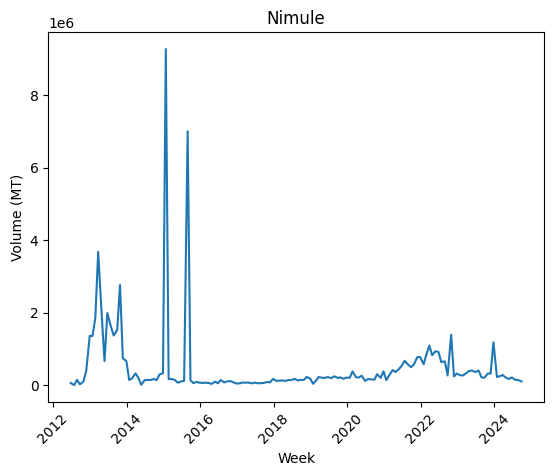

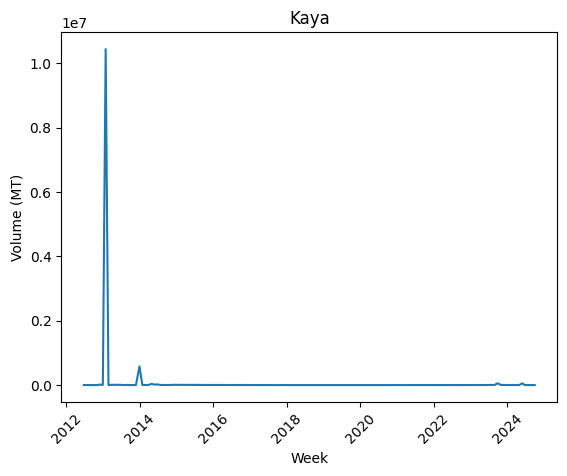

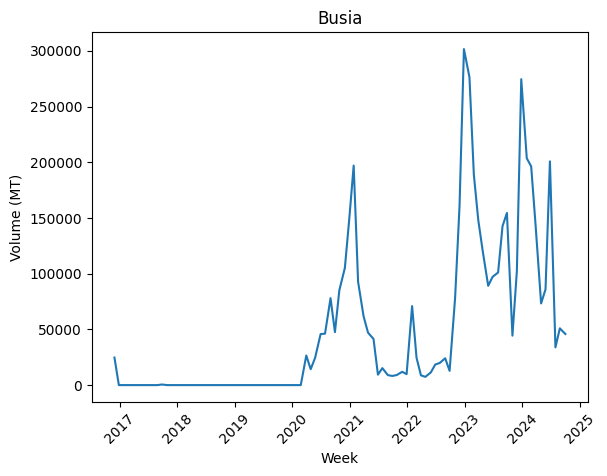

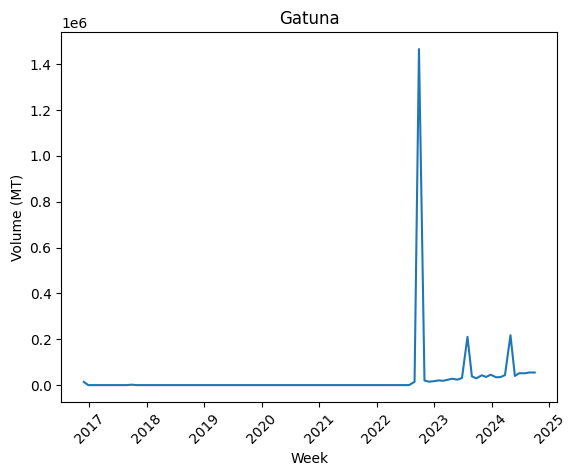

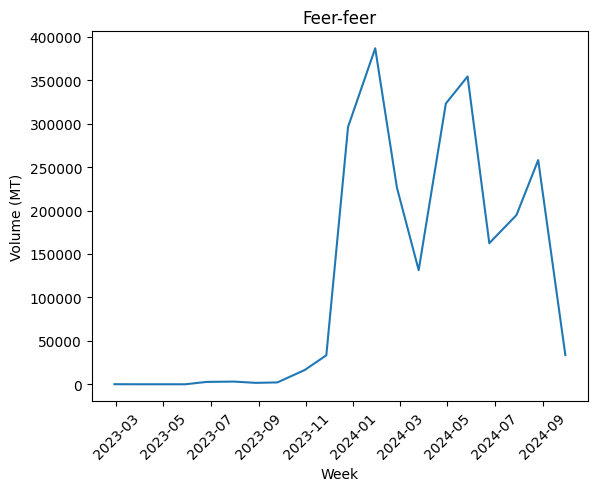

In [16]:
#lets plot to see time series analysis
for border in top_borders:
  subset = weekly_top[weekly_top['border_point']==border]
  plt.figure()
  plt.plot(subset['week'], subset['quantity_mt'])
  plt.title(border)
  plt.xlabel("Week")
  plt.ylabel("Volume (MT)")
  plt.xticks(rotation=45)
  plt.show()

Anomaly detection: compute z-scores on rolling 30-day averages; flag weeks where volume drops below -2 sigma; create a timeline of anomalous periods per border point; annotate known events (elections, COVID, conflicts)

In [31]:
#Anomaly detection using z-score
df = df.sort_values(['border_point','period_date'])
df['rolling_mean'] = df.groupby('border_point')['quantity_mt'].transform(lambda x: x.rolling(4, min_periods=1).mean())

df['rolling_std'] = df.groupby('border_point')['quantity_mt'].transform(lambda x: x.rolling(4, min_periods=1).std())

df['z_score']  = (df['quantity_mt'] - df['rolling_mean']) / df['rolling_std']
df['anomaly'] = df['z_score'] < -2

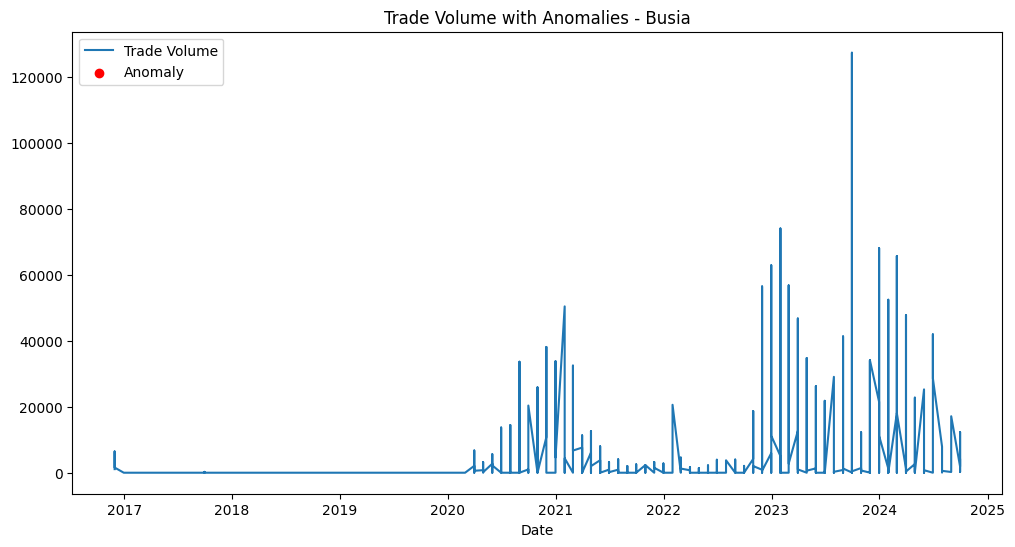

In [32]:
#check anomalies using a specific border
border = 'Busia' # we can change
df_border = df[df['border_point']==border]
plt.figure(figsize=(12,6))

plt.plot(df_border['period_date'], df_border['quantity_mt'], label='Trade Volume')

#anomalies
anomalies = df_border[df_border['anomaly'] == True]
plt.scatter(anomalies['period_date'], anomalies['quantity_mt'],
            color='red', label='Anomaly',zorder=5)

plt.title(f'Trade Volume with Anomalies - {border}')
plt.xlabel('Date')
plt.legend()
plt.show()

In [33]:
df.groupby('border_point')['anomaly'].sum().sort_values(ascending=False)

,anomaly
border_point,
Balho,0
Beled Weyn,0
Belet Hawo,0
Busia,0
Buuhoodle,0
Doblei,0
Feer-feer,0
Galafi,0
Galila,0


In [34]:
anomalies = df[df['anomaly']]
anomaly_summary = anomalies.groupby(['border_point', 'period_date']).size().reset_index(name='count')

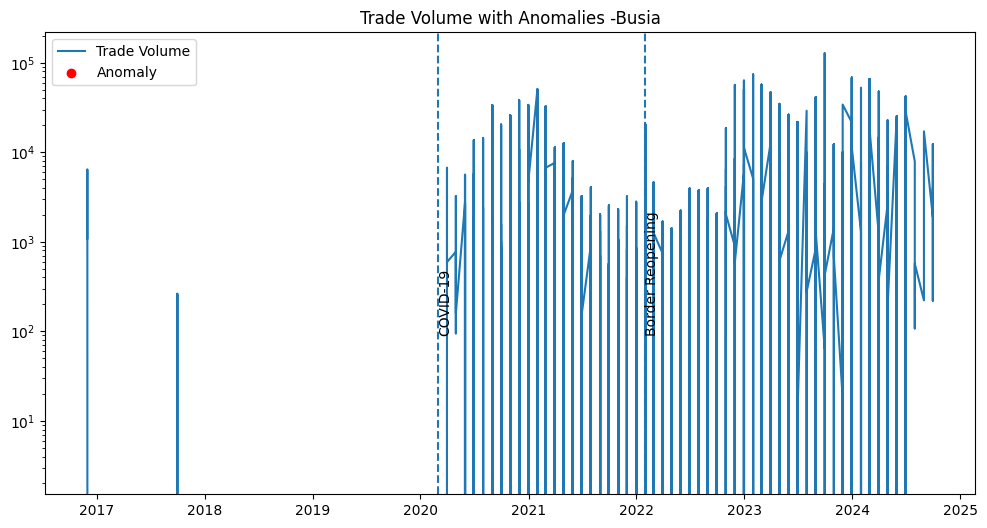

In [38]:
#Check anomalies with specific period of covid
#y position
plt.figure(figsize=(12,6))

plt.plot(df_border['period_date'], df_border['quantity_mt'], label='Trade Volume')

#anomalies
anomalies = df_border[df_border['anomaly'] == True]
plt.scatter(anomalies['period_date'], anomalies['quantity_mt'],
            color='red', label='Anomaly',zorder=5)

y_pos = df_border['quantity_mt'].median()
#event lines
plt.axvline(x=pd.to_datetime('2020-03-01'), linestyle='--')
plt.text(pd.to_datetime('2020-03-01'),y_pos, 'COVID-19', rotation=90)

plt.axvline(x=pd.to_datetime('2022-01-31'), linestyle='--')
plt.text(pd.to_datetime('2022-01-31'),y_pos, 'Border Reopening', rotation=90)

plt.yscale('log')
plt.title(f'Trade Volume with Anomalies -{border}')
plt.legend()
plt.show()

Commodity composition analysis: for each border, stacked area chart of commodity shares over time; annotate when commodity mix shifts (e.g., livestock disappears, grains surge)

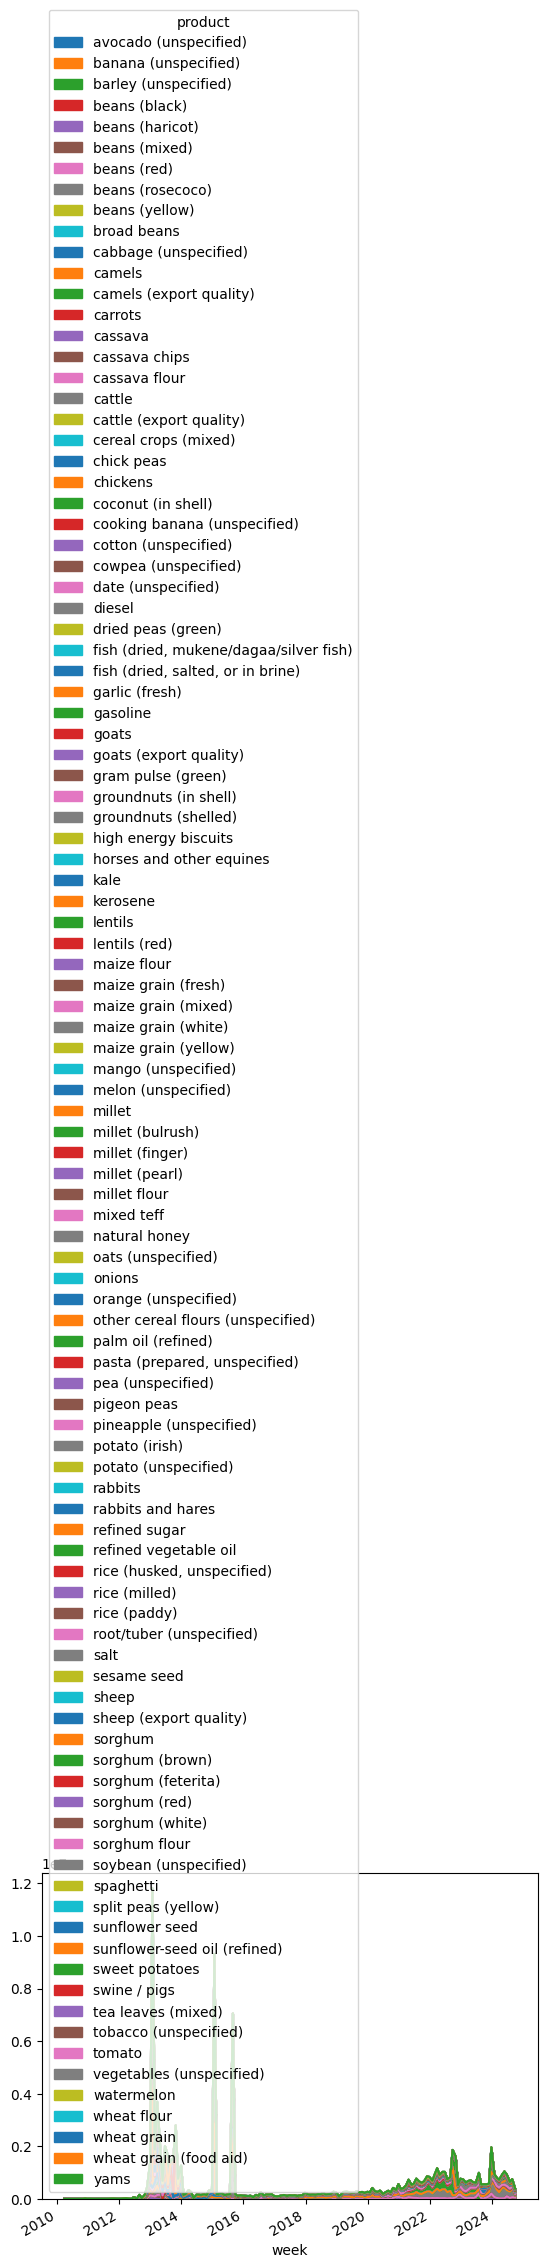

In [ ]:
#commodity composition
commodity_weekly = df.groupby(['week','product'])['quantity_mt'].sum().unstack().fillna(0)
commodity_weekly.plot.area()
plt.show()

In [39]:
#let's check each border (e.g Busia)
border = 'Busia'
df_border = df[df['border_point'] == border]
commodity_weekly = df_border.groupby(['week','product'])['quantity_mt'].sum().unstack().fillna(0)

In [40]:
commodity_share = commodity_weekly.div(commodity_weekly.sum(axis=1), axis=0)

<Figure size 1200x600 with 0 Axes>

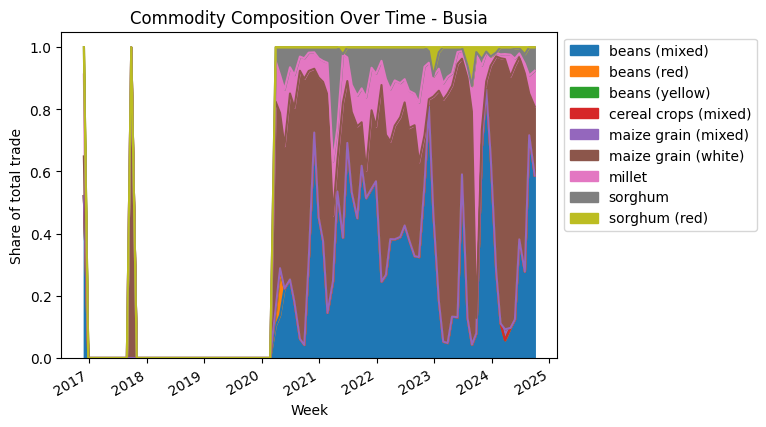

In [44]:
plt.figure(figsize=(12,6))
commodity_share.plot.area()
plt.title(f'Commodity Composition Over Time - {border}')
plt.ylabel('Share of total trade')
plt.xlabel('Week')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.show()

Cross-border comparison: when Kenya-Uganda trade drops at Busia, does Kenya-Somalia trade at Moyale compensate? Correlation analysis of volumes across borders; annotate substitution effects

In [45]:
#cross border comparision, will use correlation
pivot  = weekly.pivot(index = 'week', columns='border_point', values='quantity_mt')
corr_matrix = pivot.corr()
print(corr_matrix)


border_point  Balho  Beled Weyn  Belet Hawo     Busia  Buuhoodle    Doblei  \
border_point                                                                 
Balho           NaN         NaN         NaN       NaN        NaN       NaN   
Beled Weyn      NaN    1.000000    0.007327  0.664696   0.392167 -0.019760   
Belet Hawo      NaN    0.007327    1.000000  0.204441   0.008290  0.032832   
Busia           NaN    0.664696    0.204441  1.000000  -0.109881  0.319657   
Buuhoodle       NaN    0.392167    0.008290 -0.109881   1.000000 -0.047648   
Doblei          NaN   -0.019760    0.032832  0.319657  -0.047648  1.000000   
Feer-feer       NaN   -0.603046    0.020175  0.195297   0.394366 -0.015656   
Galafi          NaN    0.389808    0.128637       NaN   0.280838 -0.002620   
Galila          NaN    0.361635    0.219549       NaN  -0.089133  0.265829   
Gambella        NaN         NaN    1.000000 -1.000000  -1.000000 -1.000000   
Gatuna          NaN   -0.002704    0.002683  0.023465  -0.095217

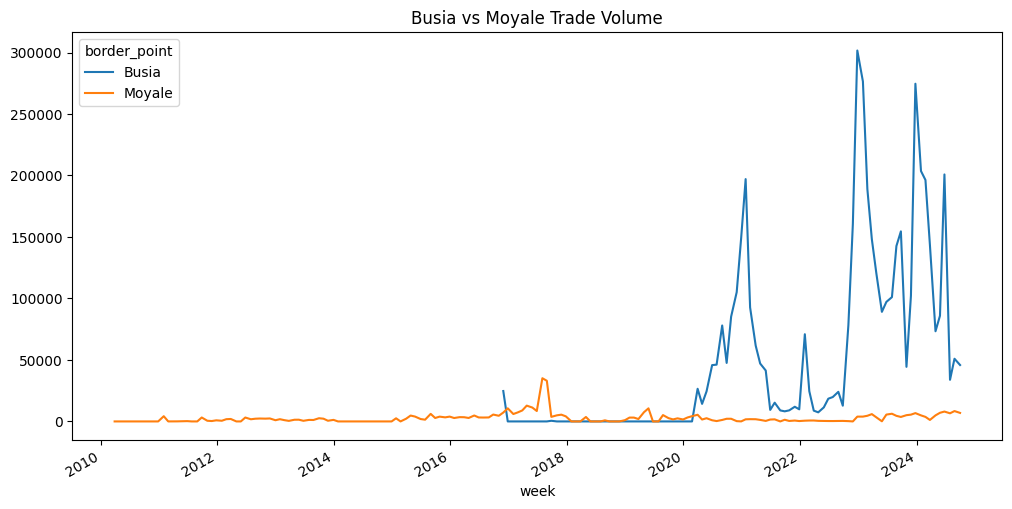

In [46]:
#check correlation on specific borders
pivot[['Busia','Moyale']].plot(figsize=(12,6))
plt.title('Busia vs Moyale Trade Volume')
plt.show()

In [47]:
pivot[['Busia', 'Moyale']].corr()

border_point,Busia,Moyale
border_point,,
Busia,1.000000,-0.025142
Moyale,-0.025142,1.000000


correlation coefficient(-0.025) is effectively 0, indicates that changes in trade volume at one border do not predict or offset changes changes at other

Seasonality: decompose top 3 crossing points into trend + seasonal + residual; overlay all three seasonal components; annotate whether they share agricultural calendar patterns

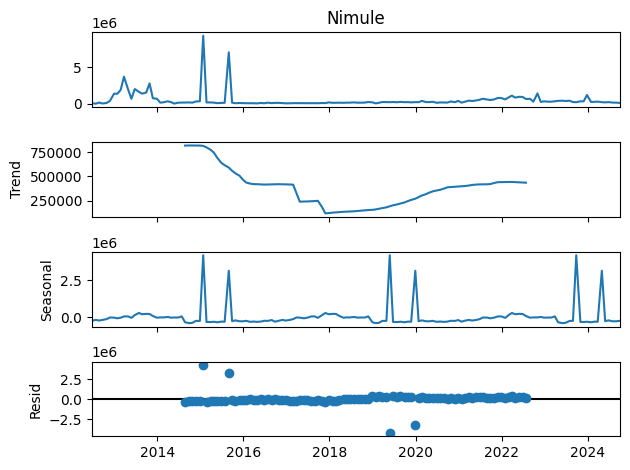

In [55]:
#only for one border
series = pivot[top_borders[0]].dropna()
decomp = seasonal_decompose(series, model='additive', period=52)
decomp.plot()
plt.show()

In [56]:
#on the above seasonal decomposition done only for one border point
#now for top 3
seasonals = {}
for border in top_borders[:3]:
  series = pivot[border].dropna()
  decomp = seasonal_decompose(series, model='additive',period = 26)
  seasonals[border] = decomp.seasonal

requires 104 observations. x only has 95 observation(s). because of this i make it to use six months

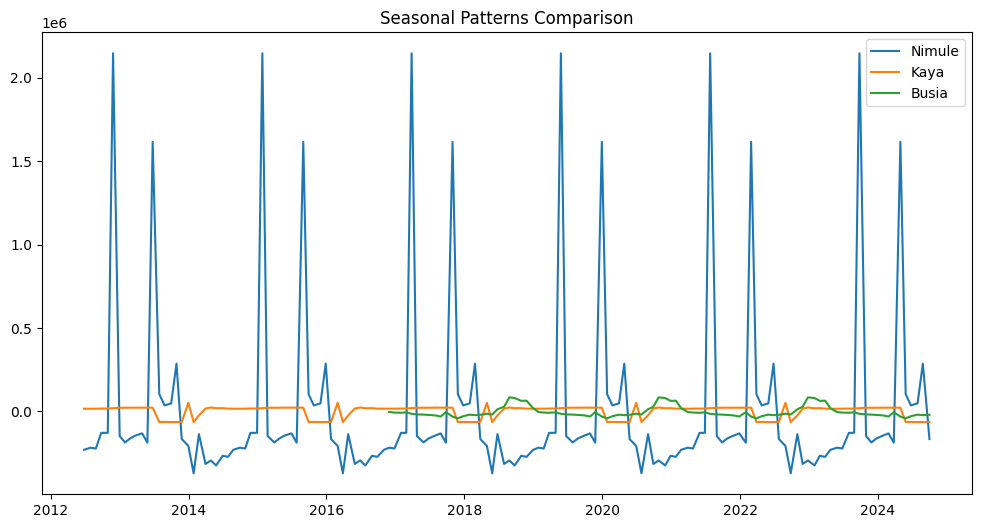

In [58]:
plt.figure(figsize=(12,6))
for border in seasonals:
  plt.plot(seasonals[border], label=border)

  plt.title('Seasonal Patterns Comparison')
plt.legend()
plt.show()

Build a simple alert system: define rules for "suspicious drop" (>40% decline week-over-week + not seasonal); list all triggered alerts; annotate which ones correspond to real events

In [64]:
#alert system
df['pct_change'] = df['quantity_mt'].pct_change()
df['alert'] = (df['pct_change']< -0.4) & (df['z_score']<-2)

alerts = df[df['alert']].copy()
print(alerts[['period_date','quantity_mt','pct_change','z_score']])

Empty DataFrame
Columns: [period_date, quantity_mt, pct_change, z_score]
Index: []


In [78]:
real_events = {
    "2023-05-12":"Border closure(EAC dispute)",# Busia: between kenya and uganda related to non-tariff barriers, truck delays
    "2022-11-03":"Livestock export ban",
    "2023-01-20":"Security operation near Moyale",
}

df['event_annotation'] = df['period_date'].astype(str).map(real_events).fillna(" ")



In [79]:
df['event_annotation'] = df['period_date'].astype(str).map(real_events).fillna(" ")

#filter alerts with event annotation
alerts = df[df['alert']][['period_date','quantity_mt','pct_change','z_score','event_annotation']]
print(alerts)

Empty DataFrame
Columns: [period_date, quantity_mt, pct_change, z_score, event_annotation]
Index: []


In [80]:
df[['quantity_mt', 'pct_change']].head(10)

,quantity_mt,pct_change
22712,0.30,NaN
22740,3.50,10.666667
22766,1.00,-0.714286
22764,1.50,0.500000
21542,0.00,-1.000000
21564,87.00,inf
21558,122.00,0.402299
21554,18.00,-0.852459
21555,37.65,1.091667
21563,182.30,3.841965


In [81]:
for __,row in alerts.iterrows():

  plt.text(row['period_date'],row['quantity_mt'],'Alert')


In [82]:
anomalies = df[df['alert']]
print(anomalies)

Empty DataFrame
Columns: [reporting_country, reporting_country_code, border_point, source, source_country_code, destination, destination_country_code, cpcv2, product, indicator_name, start_date, period_date, value, flow_type, trade_type, collection_status, source_organization, source_document, dataseries_name, dataseries, unit, unit_type, unit_name, status, common_unit, common_unit_quantity, reporting_country_geographic_group, reporting_country_fewsnet_region, source_geographic_group, source_fewsnet_region, destination_geographic_group, destination_fewsnet_region, value_one_month_ago, pct_change_from_one_month_ago, collection_schedule, data_usage_policy, year, month, unit_clean, unit_size, unit_type_clean, total_base_qty, quantity_mt, week, rolling_mean, rolling_std, z_score, anomally, anomaly, pct_change, alert, event_annotation]
Index: []

[0 rows x 52 columns]


In [83]:
df['abs_change'] = df.groupby('border_point')['quantity_mt'].diff()
df['alert'] = df['abs_change'].abs() > df['abs_change'].std()

In [84]:
alerts = df[df['alert'] ==True]
alerts

,reporting_country,reporting_country_code,border_point,source,source_country_code,destination,destination_country_code,cpcv2,product,indicator_name,...,week,rolling_mean,rolling_std,z_score,anomally,anomaly,pct_change,alert,event_annotation,abs_change
17273,Uganda,UG,Busia,Tanzania,TZ,Uganda,UG,R01182AA,millet,TradeFlowQuantity,...,2023-09-25,33103.33475,62850.124962,1.499561,False,False,1960.780439,True,,127286.023
17324,Uganda,UG,Busia,Uganda,UG,Kenya,KE,R01142AA,sorghum,TradeFlowQuantity,...,2023-09-25,32217.50575,63424.647400,-0.505175,False,False,-0.998610,True,,-127173.955
40243,Somalia,SO,Feer-feer,Ethiopia,ET,Somalia,SO,P33360AA,diesel,TradeFlowQuantity,...,2023-12-25,73618.37500,147004.508465,1.499999,False,False,inf,True,,294125.000
40284,Somalia,SO,Feer-feer,Ethiopia,ET,Somalia,SO,R01701AG,beans (red),TradeFlowQuantity,...,2023-12-25,73531.25000,147062.500000,-0.500000,False,False,-1.000000,True,,-294125.000
40388,Somalia,SO,Feer-feer,Ethiopia,ET,Somalia,SO,P33360AA,diesel,TradeFlowQuantity,...,2024-01-29,96321.35000,191786.381461,1.499995,False,False,345.726862,True,,382892.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80126,South Sudan,SS,Nimule,Kenya,KE,South Sudan,SS,L02121AA,camels,TradeFlowQuantity,...,2024-06-24,40270.29675,47727.029119,-0.843763,False,False,-1.000000,True,,-95326.626
80418,"Tanzania, United Republic of",TZ,Tarakea,"Tanzania, United Republic of",TZ,Kenya,KE,R01122AC,maize grain (white),TradeFlowQuantity,...,2024-06-24,20193.50000,40264.426760,1.499997,False,False,436.989130,True,,80406.000
80581,"Tanzania, United Republic of",TZ,Tarakea,"Tanzania, United Republic of",TZ,Kenya,KE,R01122AC,maize grain (white),TradeFlowQuantity,...,2024-07-29,21053.25000,42036.513726,1.500000,False,False,1037.370370,True,,84027.000
80576,"Tanzania, United Republic of",TZ,Tarakea,Kenya,KE,"Tanzania, United Republic of",TZ,R01706AA,cowpea (unspecified),TradeFlowQuantity,...,2024-07-29,21085.25000,42015.188185,-0.498802,False,False,-0.998478,True,,-83980.000


In [85]:
df[df['alert'] == True]['border_point'].value_counts()

,count
border_point,
Nimule,278
Feer-feer,18
Gatuna,10
Mpondwe,4
Kaya,4
Tarakea,4
Busia,2


In [86]:
border = 'Nimule' #as an example
df_border = df[(df['border_point']==border) & (df['alert'] == True)]
df_border = df_border.sort_values('period_date')
df_border[['period_date','quantity_mt','abs_change']]

,period_date,quantity_mt,abs_change
799,2012-12-31,123758.880,80226.780
812,2012-12-31,0.000,-123758.880
859,2012-12-31,176654.941,176654.941
857,2012-12-31,58872.632,-117782.309
815,2012-12-31,213657.390,154784.758
...,...,...,...
78441,2024-02-29,0.000,-108169.657
78824,2024-03-31,100239.120,100239.120
19702,2024-04-30,379.000,-86297.912
20414,2024-06-30,0.000,-77577.619


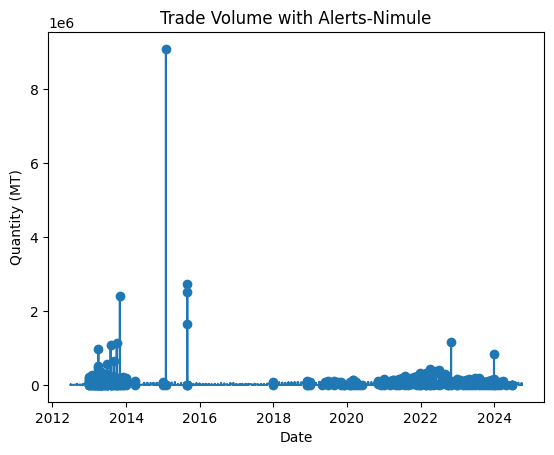

In [87]:
df_border = df[df['border_point']=='Nimule'].sort_values('period_date')
plt.figure()
plt.plot(df_border['period_date'],df_border['quantity_mt'])
plt.scatter(df_border[df_border['alert']]['period_date'],
            df_border[df_border['alert']]['quantity_mt'])
plt.title('Trade Volume with Alerts-Nimule')
plt.xlabel('Date')
plt.ylabel('Quantity (MT)')
plt.show()

In [88]:
df[df['alert'] == True]['product'].value_counts()

,count
product,
gasoline,51
diesel,46
rice (milled),25
refined sugar,21
refined vegetable oil,20
maize flour,17
wheat flour,15
kerosene,13
maize grain (white),13


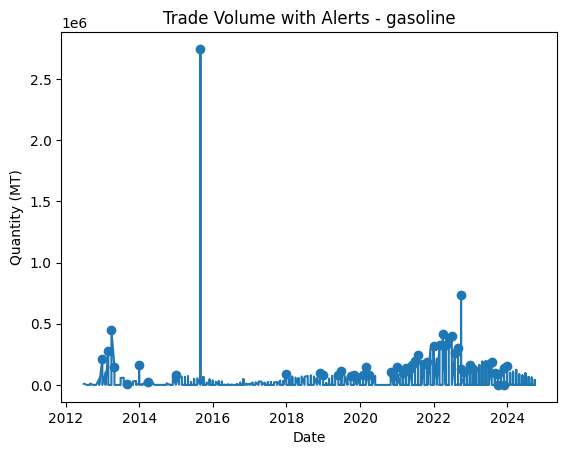

In [89]:
product = 'gasoline'
df_prod = df[(df['product'] == product)].sort_values('period_date')
plt.figure()
plt.plot(df_prod['period_date'], df_prod['quantity_mt'])
plt.scatter(df_prod[df_prod['alert']]['period_date'],
            df_prod[df_prod['alert']]['quantity_mt'])

plt.title(f'Trade Volume with Alerts - {product}')
plt.xlabel('Date')
plt.ylabel('Quantity (MT)')
plt.show()

In [90]:
df[df['alert'] == True]['reporting_country'].value_counts()

,count
reporting_country,
South Sudan,282
Somalia,18
Rwanda,10
Uganda,6
"Tanzania, United Republic of",4


In [91]:
df[df['alert']== True]['destination'].value_counts()

,count
destination,
South Sudan,282
Somalia,14
Rwanda,8
Ethiopia,4
Kenya,4
Democratic Republic of the Congo,4
"Congo, The Democratic Republic of the",2
Uganda,1
"Tanzania, United Republic of",1


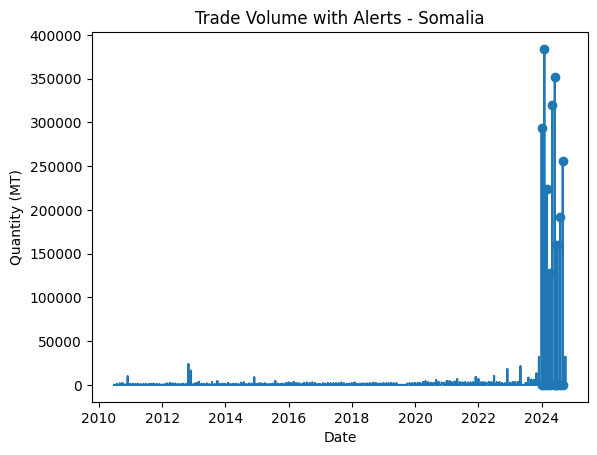

In [92]:
country = 'Somalia'
df_country = df[df['reporting_country'] == country].sort_values('period_date')

plt.figure()
plt.plot(df_country['period_date'], df_country['quantity_mt'])
plt.scatter(df_country[df_country['alert']]['period_date'],
            df_country[df_country['alert']]['quantity_mt'])

plt.title(f'Trade Volume with Alerts - {country}')
plt.xlabel('Date')
plt.ylabel('Quantity (MT)')
plt.show()

Alerts count by border + product

In [94]:
df[df['alert'] == True].groupby(['border_point', 'product']).size().sort_values(ascending=False)

border_point  product                               
Nimule        gasoline                                  50
              diesel                                    37
              rice (milled)                             23
              refined sugar                             20
              maize flour                               17
              refined vegetable oil                     15
              wheat flour                               14
              sheep                                     12
              sorghum (brown)                           11
              kerosene                                  10
              maize grain (white)                       10
              beans (mixed)                             10
Feer-feer     diesel                                     9
Nimule        cattle                                     9
              cassava chips                              8
              groundnuts (shelled)                       8
              camels                                     6
              goats                                      6
              cassava                                    4
              sesame seed                                3
              sorghum                                    3
Feer-feer     refined vegetable oil                      2
Tarakea       maize grain (white)                        2
Kaya          kerosene                                   2
Mpondwe       palm oil (refined)                         2
Feer-feer     rice (milled)                              2
Gatuna        refined vegetable oil                      2
Feer-feer     refined sugar                              1
              beans (red)                                1
              cattle                                     1
Busia         millet                                     1
              sorghum                                    1
Feer-feer     camels                                     1
              wheat flour                                1
Gatuna        potato (unspecified)                       1
              potato (irish)                             1
              palm oil (refined)                         1
              kerosene                                   1
              fish (dried, salted, or in brine)          1
              gasoline                                   1
              cooking banana (unspecified)               1
Mpondwe       fish (dried, mukene/dagaa/silver fish)     1
Nimule        cassava flour                              1
Kaya          maize grain (white)                        1
Mpondwe       millet                                     1
Gatuna        sunflower-seed oil (refined)               1
Kaya          refined vegetable oil                      1
Nimule        sorghum (red)                              1
Tarakea       cowpea (unspecified)                       1
              groundnuts (shelled)                       1
dtype: int64

In [96]:
weekly  = df.groupby(['border_point','week'])['quantity_mt'].sum().reset_index()
weekly_alerts = df[df['alert']== True]

In [97]:
df.shape

(81492, 53)

In [98]:
df.to_csv('cleaned_fewsnet_trade.csv',index = False)